In [170]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder,OrdinalEncoder,OneHotEncoder

## Loading Dataset

In [172]:
exercise = pd.read_csv("exercise.csv")
calories = pd.read_csv("calories.csv")

In [173]:
#Merging the two dataframes into one based on User_ID column
data = pd.merge(exercise,calories,on='User_ID')

In [174]:
data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [175]:
data.shape

(15000, 9)

In [176]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [177]:
data.describe().drop('User_ID',axis=1)

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


## EDA - Getting some visual insights on the data

In [179]:
data_cp=data

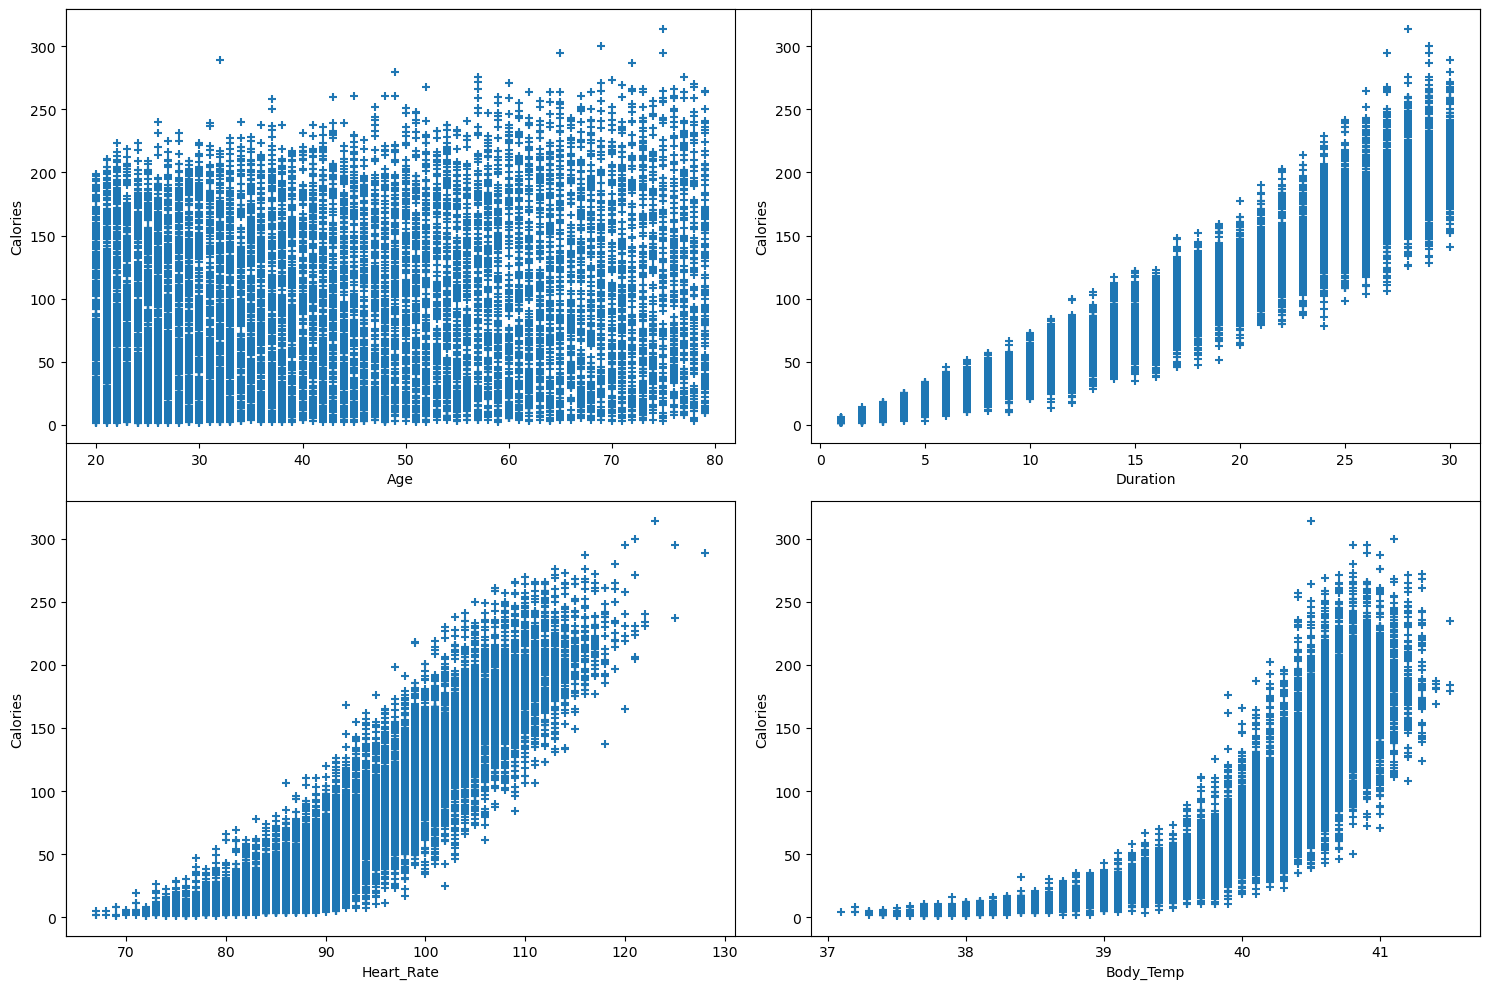

In [180]:
cols = ["Age","Duration","Heart_Rate","Body_Temp"]

fig , axes = plt.subplots(figsize = (15,10))
for i , col in enumerate(cols):
    plt.subplot(2,2,i+1)
    plt.scatter(data_cp[col],data_cp['Calories'],marker='+')
    plt.xlabel(col)
    plt.ylabel("Calories")
axes.set_xticks([])
axes.set_yticks([])
plt.tight_layout()
plt.show()

In [181]:
# bins = [1,20,40,60,80,100]
# labels = ['1-20','21-40','41-60','61-80','81-100']
# data_cp['Age_Category'] = pd.cut(data_cp['Age'], bins=bins, labels=labels, include_lowest=True)

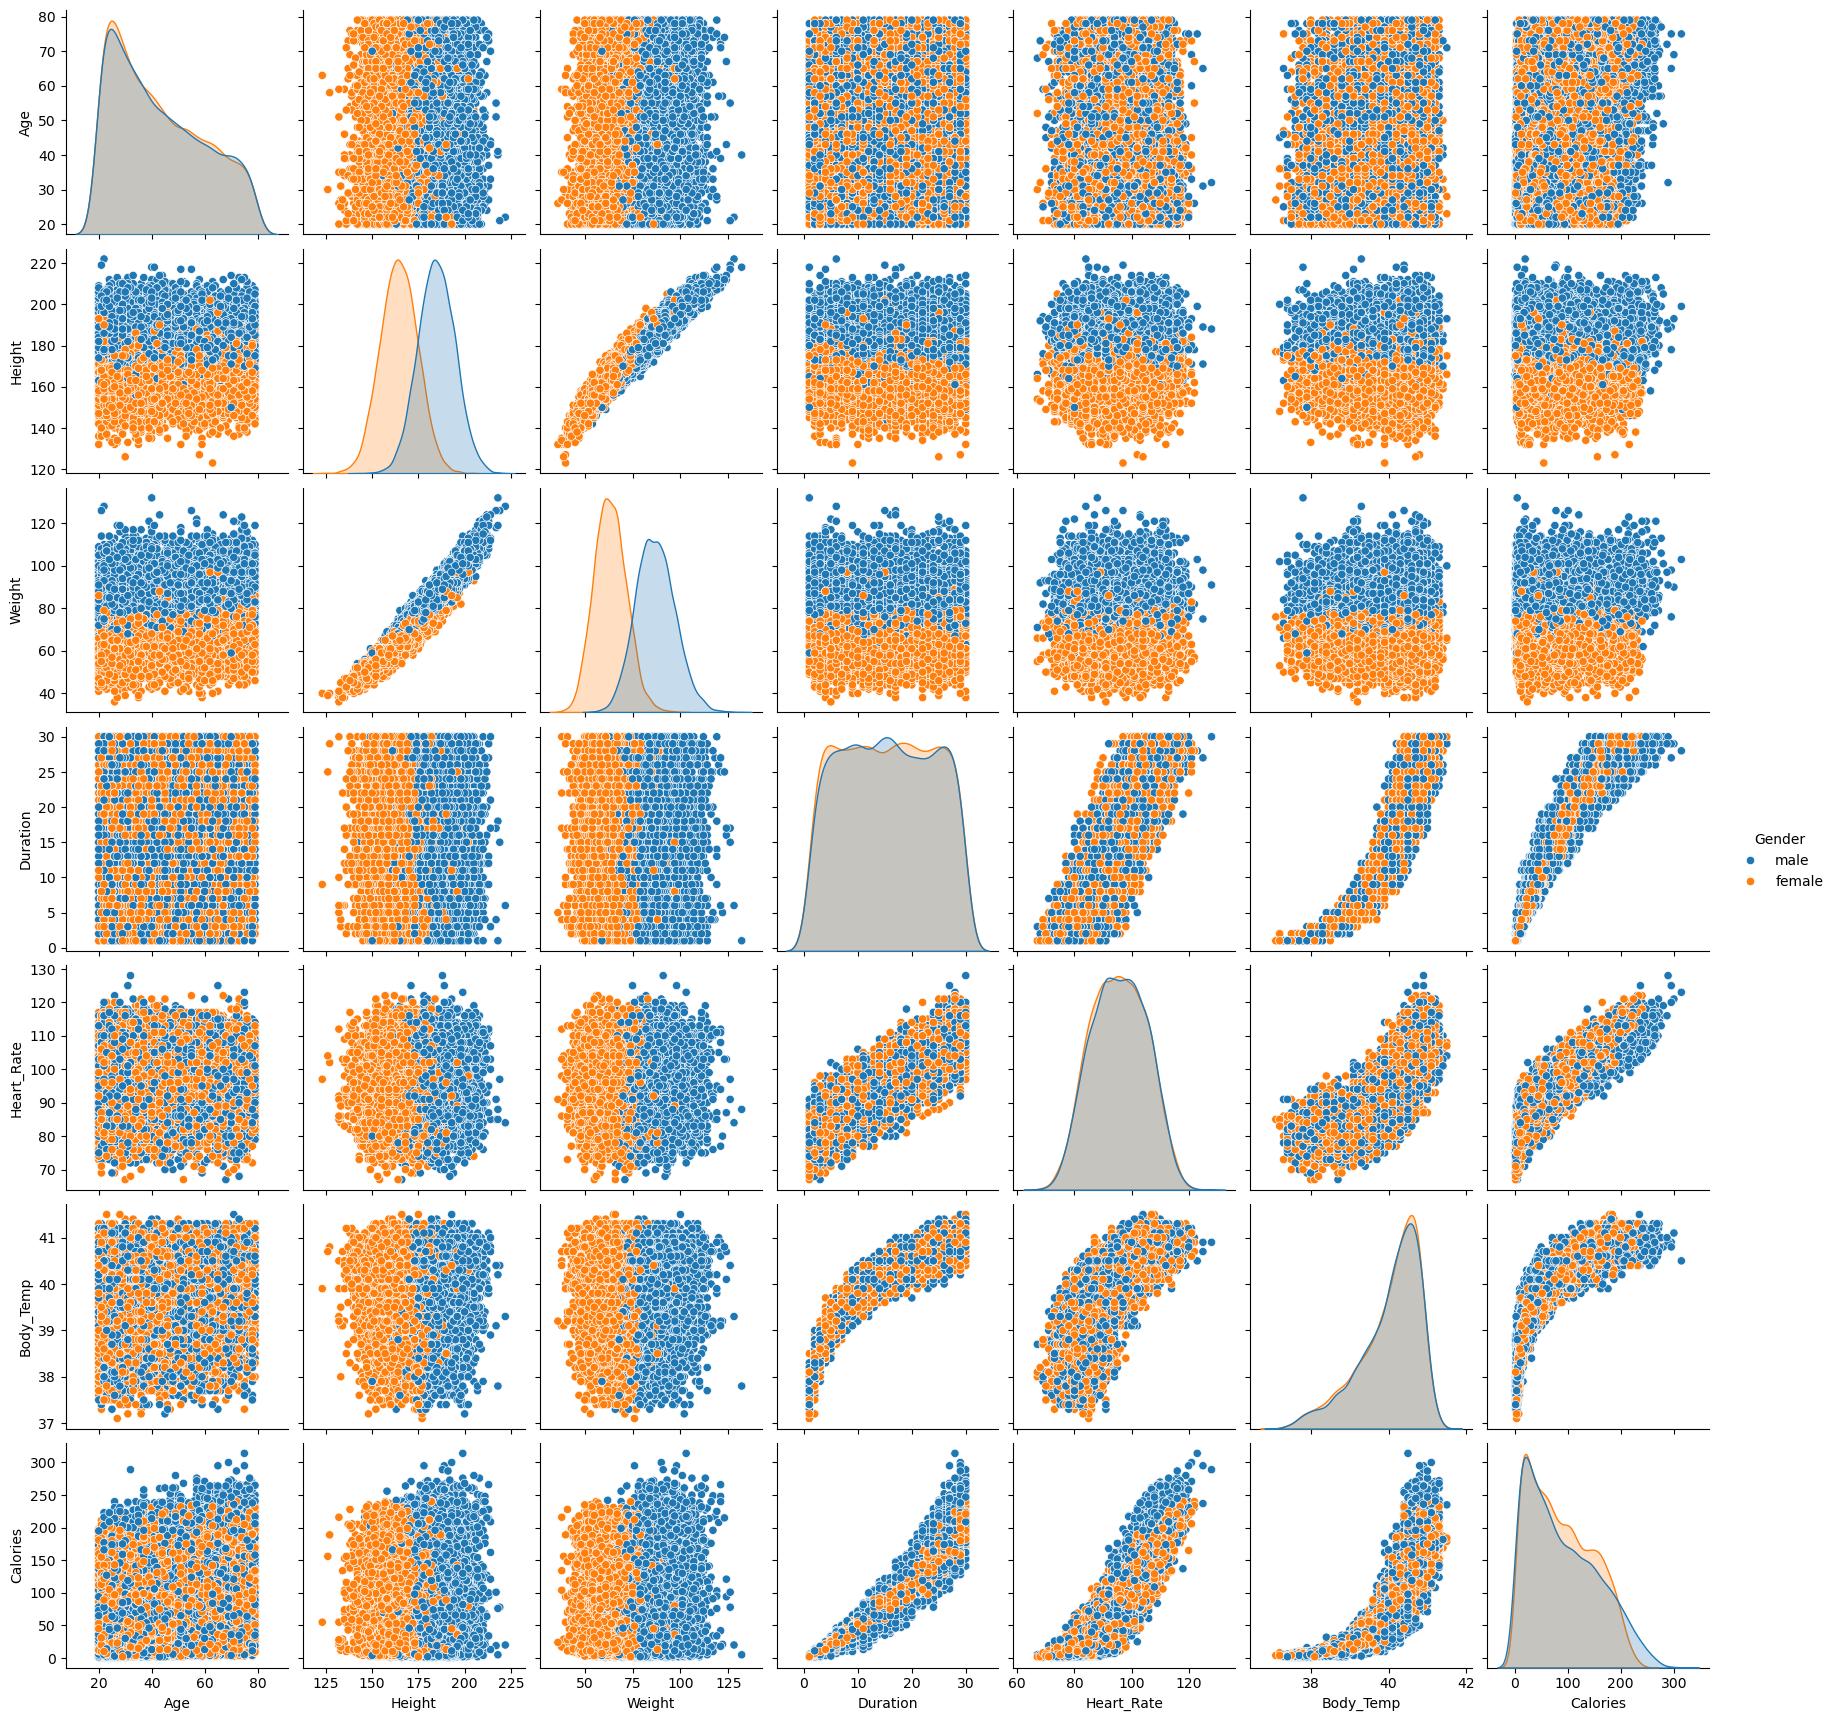

In [196]:
data_cp = data_cp.drop('User_ID',axis=1)
custom_palette = {'Male': 'lightblue', 'Female': 'pink'}
sns.pairplot(data_cp, hue='Gender')
plt.show()

#### Some insights on dataset:
- As the duration increases the calories burnt increases
- Same is the trend observed with heart rate and body temperature

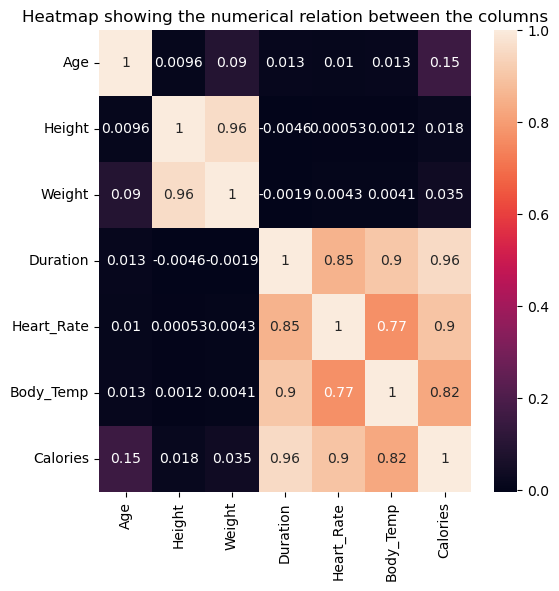

In [207]:
numeric_columns = data_cp.select_dtypes(include=np.number).columns.tolist()
corr_data = data_cp[numeric_columns].corr()

plt.figure(figsize=(6,6))
sns.heatmap(data=corr_data , annot = True)
plt.title("Heatmap showing the numerical relation between the columns")
plt.show()

#### Dropping columns:
- Both height and weight have similar impact, we can drop one of these columns.
- The duration has high correlation with calories which might lead to data leakage - our model will perform well for training dataset but will fail to apply on real world usecases.

In [213]:
data_cp = data_cp.drop(columns=["Height","Duration"],axis=1)
data_cp.head()

,Gender,Age,Weight,Heart_Rate,Body_Temp,Calories
0,male,68,94.0,105.0,40.8,231.0
1,female,20,60.0,94.0,40.3,66.0
2,male,69,79.0,88.0,38.7,26.0
3,female,34,71.0,100.0,40.5,71.0
4,female,27,58.0,81.0,39.8,35.0


### Applying one hot encoding to Gender column - converting categorical data to numerical values

In [215]:
data_cp_encoded = pd.get_dummies(data_cp,columns=['Gender'],drop_first=True,dtype='int')
data_cp_encoded.head()

,Age,Weight,Heart_Rate,Body_Temp,Calories,Gender_male
0,68,94.0,105.0,40.8,231.0,1
1,20,60.0,94.0,40.3,66.0,0
2,69,79.0,88.0,38.7,26.0,1
3,34,71.0,100.0,40.5,71.0,0
4,27,58.0,81.0,39.8,35.0,0


In [164]:
# sns.histplot(data=data_cp_encoded,x=data_cp_encoded['Age'],y=data_cp_encoded['Calories'],hue=data_cp_encoded['Gender_male'],multiple='dodge',kde=True)
# plt.show()